# MDenseU-Net for Colab: 2D Lung Segmentation from 3D CT Data

This notebook is a **single-file, end-to-end research workflow** for binary lung segmentation using the Kaggle dataset **Finding and Measuring Lungs in CT Data**.  
It compares:

1. **Baseline U-Net**
2. **Proposed MDenseU-Net** (Dense + Multi-scale + SE + Deep Supervision)

All sections are organized like a compact research project and are designed to run sequentially in **Google Colab (free tier, T4 GPU)**.

## 0. Setup & Installations

In this section we install dependencies, set random seeds for reproducibility, and verify runtime settings.

In [1]:
!pip -q install kaggle kagglehub nibabel SimpleITK monai torchsummary scikit-image

import os
import gc
import math
import json
import random
import zipfile
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from scipy import ndimage
from scipy.spatial.distance import cdist

from PIL import Image
import cv2

from monai.transforms import (
    Compose,
    RandFlipd,
    RandAffined,
    Rand2DElasticd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    EnsureTyped,
)

from torchsummary import summary

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Torch version:', torch.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 69.5 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device: cuda
Torch version: 2.10.0+cu128


## 1. Dataset Loading & Exploration

We download the Kaggle dataset directly inside Colab and build a robust data parser that can handle common CT formats.  


In [2]:
# Download dataset using kagglehub (no kaggle.json needed)
import kagglehub
import shutil

path = kagglehub.dataset_download("kmader/finding-lungs-in-ct-data")
print("Downloaded to:", path)

# Set DATA_ROOT to the downloaded path
DATA_ROOT = Path(path)
all_files = [p for p in DATA_ROOT.rglob('*') if p.is_file()]
print('Total files:', len(all_files))
for p in all_files[:20]:
    print('-', p)

100%|██████████| 1.03G/1.03G [00:50<00:00, 22.2MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2
Total files: 546
- /root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/2d_images.zip
- /root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/lung_stats.csv
- /root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/3d_images.zip
- /root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/2d_masks.zip
- /root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/3d_images/MASK_0078.nii.gz
- /root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/3d_images/IMG_0059.nii.gz
- /root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/3d_images/IMG_0031.nii.gz
- /root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/3d_images/MASK_0031.nii.gz
- /root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/3d_images/MASK_0059.nii.gz
- /root/.ca

In [4]:
from pathlib import Path
import os

# Find images and masks by folder name instead of filename keywords
def discover_image_mask_pairs(root: Path):
    # Try folder-based discovery first (this dataset uses 2d_images / 2d_masks)
    image_dirs = []
    mask_dirs = []

    for d in sorted(root.rglob('*')):
        if not d.is_dir():
            continue
        dname = d.name.lower()
        if any(t in dname for t in ['mask', 'seg', 'label', 'gt']):
            mask_dirs.append(d)
        elif any(t in dname for t in ['image', 'img', 'scan', 'ct', 'raw']):
            image_dirs.append(d)

    print(f"Image folders found: {image_dirs}")
    print(f"Mask folders found:  {mask_dirs}")

    pairs = []

    if image_dirs and mask_dirs:
        # Pair files by matching stem (remove _mask suffix if present)
        img_files = {}
        for d in image_dirs:
            for f in sorted(d.iterdir()):
                if f.is_file():
                    img_files[f.stem.lower()] = f

        for d in mask_dirs:
            for f in sorted(d.iterdir()):
                if f.is_file():
                    # strip common mask suffixes to find matching image
                    key = f.stem.lower()
                    for suffix in ['_mask', '_seg', '_label', '_gt', '_lung']:
                        key = key.replace(suffix, '')
                    if key in img_files:
                        pairs.append((img_files[key], f))

    # Fallback: filename-based pairing if folder method found nothing
    if not pairs:
        print("Folder-based pairing failed, trying filename-based...")
        valid_ext = {'.npy','.npz','.png','.jpg','.jpeg',
                     '.tif','.tiff','.bmp','.nii','.gz','.mhd','.mha'}
        all_files = [p for p in root.rglob('*')
                     if p.is_file() and p.suffix.lower() in valid_ext]

        mask_files, img_files = {}, {}
        for p in all_files:
            if any(t in p.name.lower() for t in ['mask','seg','label','gt']):
                mask_files[p.stem.lower()] = p
            else:
                img_files[p.stem.lower()] = p

        for stem, img in img_files.items():
            # try adding common mask suffixes
            for suffix in ['_mask', '_seg', '_label', '_gt']:
                candidate = stem + suffix
                if candidate in mask_files:
                    pairs.append((img, mask_files[candidate]))
                    break

    return pairs

pairs = discover_image_mask_pairs(DATA_ROOT)
print(f'\nDiscovered image-mask pairs: {len(pairs)}')
for p in pairs[:5]:
    print(f'  {p[0].name}  <->  {p[1].name}')

Image folders found: [PosixPath('/root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/2d_images'), PosixPath('/root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/3d_images')]
Mask folders found:  [PosixPath('/root/.cache/kagglehub/datasets/kmader/finding-lungs-in-ct-data/versions/2/2d_masks')]

Discovered image-mask pairs: 267
  ID_0000_Z_0142.tif  <->  ID_0000_Z_0142.tif
  ID_0001_Z_0146.tif  <->  ID_0001_Z_0146.tif
  ID_0002_Z_0162.tif  <->  ID_0002_Z_0162.tif
  ID_0003_Z_0132.tif  <->  ID_0003_Z_0132.tif
  ID_0004_Z_0066.tif  <->  ID_0004_Z_0066.tif


In [5]:
def to_slice_records(pairs):
    records = []
    volume_id = 0
    for img_path, mask_path in pairs:
        img = load_medical_image(img_path)
        msk = load_medical_image(mask_path)
        if img is None or msk is None:
            continue

        if img.shape != msk.shape:
            min_shape = tuple(min(a, b) for a, b in zip(img.shape, msk.shape))
            img = img[tuple(slice(0, s) for s in min_shape)]
            msk = msk[tuple(slice(0, s) for s in min_shape)]

        if img.ndim == 2:
            img = img[None, ...]
            msk = msk[None, ...]
        if img.ndim != 3:
            continue

        for z in range(img.shape[0]):
            sl_img = img[z].astype(np.float32)
            sl_msk = (msk[z] > 0).astype(np.float32)
            if np.std(sl_img) < 1e-6:
                continue
            records.append({'volume_id': volume_id, 'slice_idx': z, 'image': sl_img, 'mask': sl_msk,
                            'img_path': str(img_path), 'mask_path': str(mask_path)})
        volume_id += 1
    return records

records = to_slice_records(pairs)
print('Total slice records:', len(records))
print('Unique volumes:', len(set(r['volume_id'] for r in records)))

Total slice records: 267
Unique volumes: 267


In [6]:
volume_ids = sorted(list(set(r['volume_id'] for r in records)))
train_vids, temp_vids = train_test_split(volume_ids, test_size=0.30, random_state=SEED)
val_vids, test_vids = train_test_split(temp_vids, test_size=0.50, random_state=SEED)

train_records = [r for r in records if r['volume_id'] in train_vids]
val_records = [r for r in records if r['volume_id'] in val_vids]
test_records = [r for r in records if r['volume_id'] in test_vids]

print(f'Train/Val/Test slices: {len(train_records)}/{len(val_records)}/{len(test_records)}')
print(f'Train/Val/Test volumes: {len(train_vids)}/{len(val_vids)}/{len(test_vids)}')

Train/Val/Test slices: 186/40/41
Train/Val/Test volumes: 186/40/41


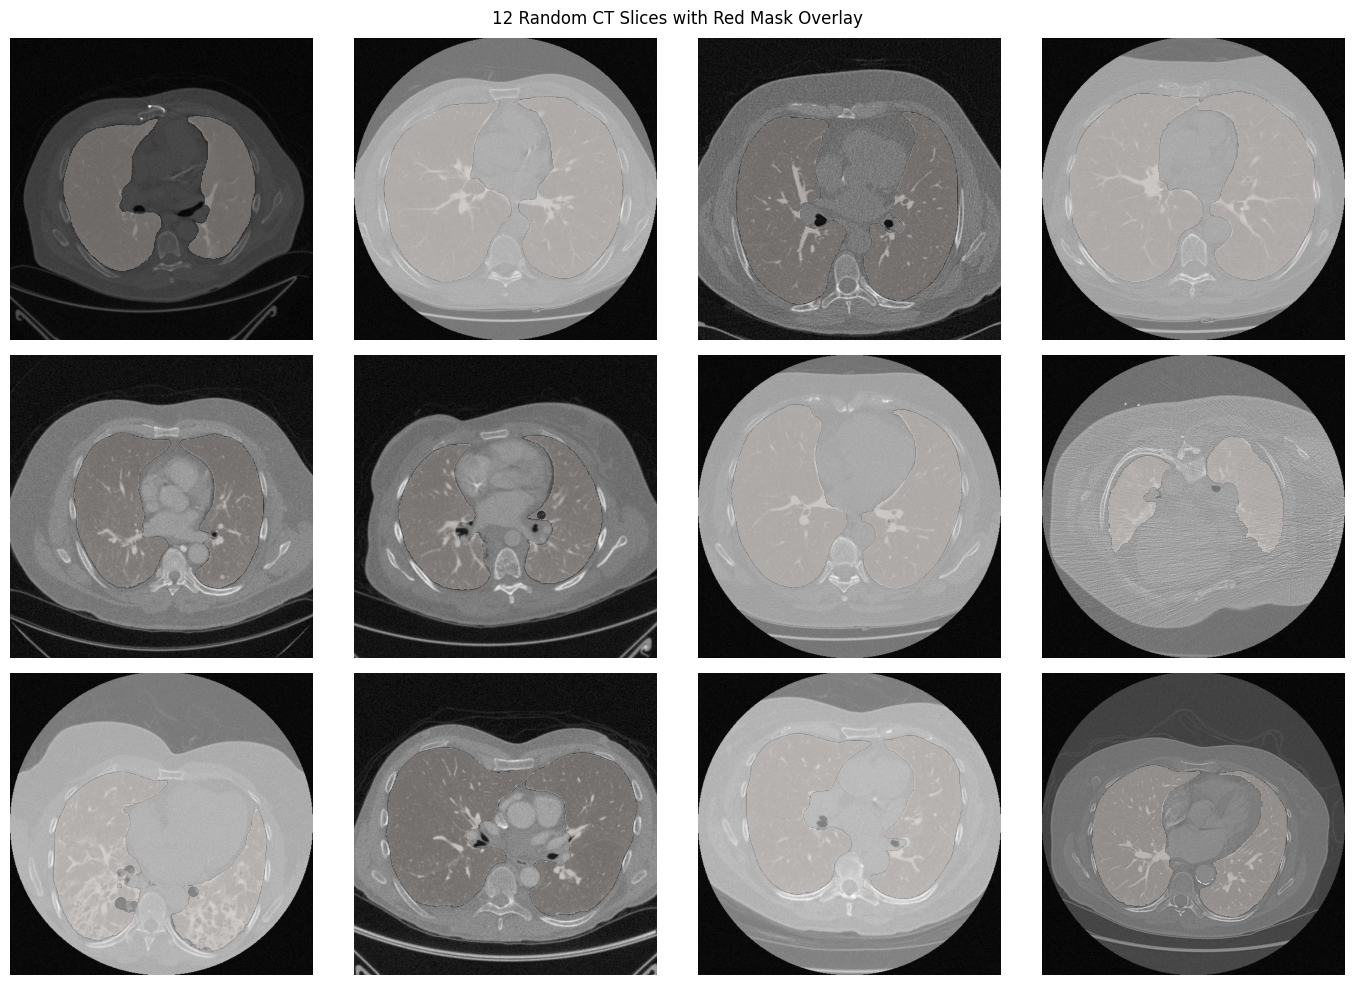

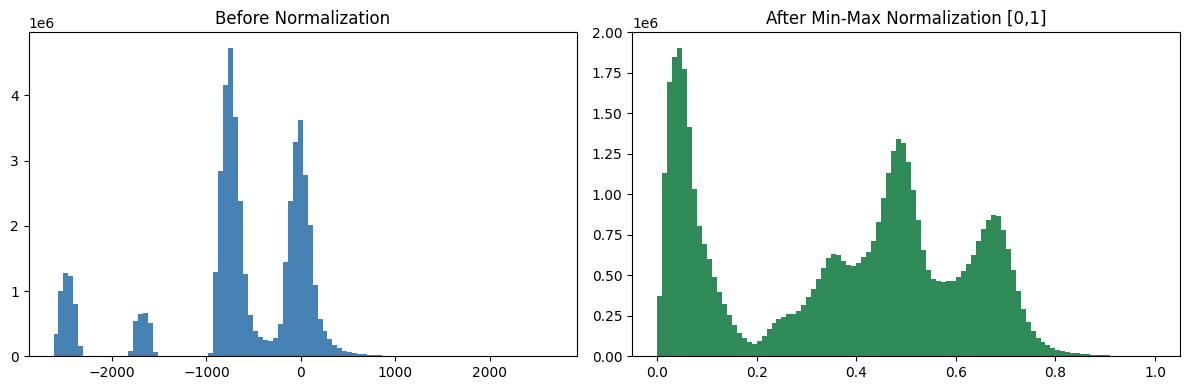

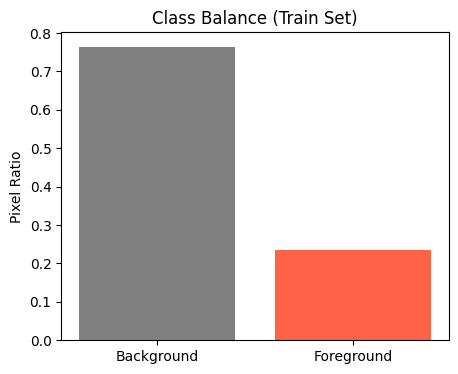

In [7]:
def minmax_norm(x):
    x = x.astype(np.float32)
    mn, mx = np.min(x), np.max(x)
    return (x - mn) / (mx - mn + 1e-8)

sample_idxs = np.random.choice(len(train_records), size=min(12, len(train_records)), replace=False)
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, idx in zip(axes.flatten(), sample_idxs):
    img = train_records[idx]['image']
    msk = train_records[idx]['mask']
    ax.imshow(minmax_norm(img), cmap='gray')
    ax.imshow(np.ma.masked_where(msk < 0.5, msk), cmap='Reds', alpha=0.4)
    ax.axis('off')
plt.suptitle('12 Random CT Slices with Red Mask Overlay')
plt.tight_layout(); plt.show()

raw_pixels = np.concatenate([r['image'].ravel() for r in train_records[:min(500, len(train_records))]])
norm_pixels = np.concatenate([minmax_norm(r['image']).ravel() for r in train_records[:min(500, len(train_records))]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw_pixels, bins=100, color='steelblue'); axes[0].set_title('Before Normalization')
axes[1].hist(norm_pixels, bins=100, color='seagreen'); axes[1].set_title('After Min-Max Normalization [0,1]')
plt.tight_layout(); plt.show()

fg = sum(np.sum(r['mask']) for r in train_records)
total = sum(r['mask'].size for r in train_records)
bg = total - fg
plt.figure(figsize=(5,4))
plt.bar(['Background', 'Foreground'], [bg/total, fg/total], color=['gray', 'tomato'])
plt.ylabel('Pixel Ratio'); plt.title('Class Balance (Train Set)')
plt.show()

## 2. Preprocessing & DataLoaders

We define normalization + resizing and strong geometric/intensity augmentation for training.  
All slices are resized to **256×256** and loaded using PyTorch DataLoader with `num_workers=2`, `pin_memory=True`.

In [8]:
IMG_SIZE = 256
BATCH_SIZE = 8

train_aug = Compose([
    RandFlipd(keys=['image', 'mask'], prob=0.5, spatial_axis=1),
    RandAffined(keys=['image', 'mask'], prob=0.5, rotate_range=(0, 0, np.deg2rad(10)), mode=('bilinear', 'nearest'), padding_mode='border'),
    Rand2DElasticd(keys=['image', 'mask'], prob=0.3, spacing=(20, 20), magnitude_range=(1, 2), mode=('bilinear', 'nearest'), padding_mode='border'),
    RandScaleIntensityd(keys=['image'], factors=0.15, prob=0.5),
    RandShiftIntensityd(keys=['image'], offsets=0.10, prob=0.5),
    EnsureTyped(keys=['image', 'mask'])
])
val_aug = Compose([EnsureTyped(keys=['image', 'mask'])])

def resize_image_mask(img, msk, size=256):
    img_r = cv2.resize(img, (size, size), interpolation=cv2.INTER_LINEAR)
    msk_r = cv2.resize(msk, (size, size), interpolation=cv2.INTER_NEAREST)
    return img_r, msk_r

class LungSliceDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        r = self.records[idx]
        img, msk = r['image'], r['mask']
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img, msk = resize_image_mask(img, msk, IMG_SIZE)
        data = {'image': img[None, ...].astype(np.float32), 'mask': msk[None, ...].astype(np.float32)}
        if self.transform is not None:
            data = self.transform(data)
        return data['image'], data['mask'], idx

train_ds = LungSliceDataset(train_records, transform=train_aug)
val_ds = LungSliceDataset(val_records, transform=val_aug)
test_ds = LungSliceDataset(test_records, transform=val_aug)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('DataLoaders ready.')

DataLoaders ready.


## 3. Architecture Implementation (U-Net)

In [30]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.enc1, self.enc2, self.enc3, self.enc4 = DoubleConv(in_ch, base), DoubleConv(base, base*2), DoubleConv(base*2, base*4), DoubleConv(base*4, base*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base*8, base*16)
        self.up4, self.dec4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2), DoubleConv(base*16, base*8)
        self.up3, self.dec3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2), DoubleConv(base*8, base*4)
        self.up2, self.dec2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2), DoubleConv(base*4, base*2)
        self.up1, self.dec1 = nn.ConvTranspose2d(base*2, base, 2, stride=2), DoubleConv(base*2, base)
        self.out_conv = nn.Conv2d(base, out_ch, 1)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2)); e4 = self.enc4(self.pool(e3)); b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1)); d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1)); d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)

## 4. Architecture Implementation (MDenseU-Net — proposed)

In [31]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(channels, hidden), nn.ReLU(inplace=True), nn.Linear(hidden, channels), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.fc(self.avg(x).view(b, c)).view(b, c, 1, 1)
        return x * w, w

class MultiScaleDenseLayer(nn.Module):
    def __init__(self, in_ch, growth_rate):
        super().__init__()
        self.conv3 = nn.Conv2d(in_ch, growth_rate, 3, padding=1, bias=False)
        self.conv5 = nn.Conv2d(in_ch, growth_rate, 5, padding=2, bias=False)
        self.conv_dil = nn.Conv2d(in_ch, growth_rate, 3, padding=2, dilation=2, bias=False)
        self.bn = nn.BatchNorm2d(growth_rate * 3)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(self.bn(torch.cat([self.conv3(x), self.conv5(x), self.conv_dil(x)], dim=1)))

class DenseMultiScaleBlock(nn.Module):
    def __init__(self, in_ch, growth_rate=16, n_layers=3):
        super().__init__()
        self.layers = nn.ModuleList(); cur_ch = in_ch
        for _ in range(n_layers):
            self.layers.append(MultiScaleDenseLayer(cur_ch, growth_rate)); cur_ch += growth_rate * 3
        self.out_ch = cur_ch
        self.se = SEBlock(self.out_ch)
        self.last_attention = None
    def forward(self, x):
        feats = [x]
        for layer in self.layers:
            feats.append(layer(torch.cat(feats, dim=1)))
        merged, w = self.se(torch.cat(feats, dim=1))
        self.last_attention = w.detach()
        return merged

class UpBlockBilinear(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class MDenseUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=24, growth=8, layers_per_block=3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(in_ch, base, 3, padding=1, bias=False), nn.BatchNorm2d(base), nn.ReLU(inplace=True))
        self.e1 = DenseMultiScaleBlock(base, growth, layers_per_block); c1 = self.e1.out_ch; self.p1 = nn.MaxPool2d(2)
        self.e2 = DenseMultiScaleBlock(c1, growth, layers_per_block); c2 = self.e2.out_ch; self.p2 = nn.MaxPool2d(2)
        self.e3 = DenseMultiScaleBlock(c2, growth, layers_per_block); c3 = self.e3.out_ch; self.p3 = nn.MaxPool2d(2)
        self.e4 = DenseMultiScaleBlock(c3, growth, layers_per_block); c4 = self.e4.out_ch; self.p4 = nn.MaxPool2d(2)
        self.b = DenseMultiScaleBlock(c4, growth, layers_per_block); cb = self.b.out_ch
        self.d4 = UpBlockBilinear(cb, c4, 192); self.d3 = UpBlockBilinear(192, c3, 128); self.d2 = UpBlockBilinear(128, c2, 96); self.d1 = UpBlockBilinear(96, c1, 64)
        self.out_main = nn.Conv2d(64, out_ch, 1); self.aux2 = nn.Conv2d(96, out_ch, 1); self.aux3 = nn.Conv2d(128, out_ch, 1)
    def forward(self, x):
        x0 = self.stem(x); e1 = self.e1(x0); e2 = self.e2(self.p1(e1)); e3 = self.e3(self.p2(e2)); e4 = self.e4(self.p3(e3)); b = self.b(self.p4(e4))
        d4 = self.d4(b, e4); d3 = self.d3(d4, e3); d2 = self.d2(d3, e2); d1 = self.d1(d2, e1)
        main = self.out_main(d1)
        aux3 = F.interpolate(self.aux3(d3), size=main.shape[-2:], mode='bilinear', align_corners=False)
        aux2 = F.interpolate(self.aux2(d2), size=main.shape[-2:], mode='bilinear', align_corners=False)
        return {'main': main, 'aux2': aux2, 'aux3': aux3}

In [32]:
unet = UNet().to(DEVICE)
mdense = MDenseUNet().to(DEVICE)
print('U-Net Summary:'); summary(unet, input_size=(1, 256, 256), device=str(DEVICE))
print('MDenseU-Net Summary:'); summary(mdense, input_size=(1, 256, 256), device=str(DEVICE))

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net trainable params: {count_params(unet):,}')
print(f'MDenseU-Net trainable params: {count_params(mdense):,}')

U-Net Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             288
       BatchNorm2d-2         [-1, 32, 256, 256]              64
              ReLU-3         [-1, 32, 256, 256]               0
            Conv2d-4         [-1, 32, 256, 256]           9,216
       BatchNorm2d-5         [-1, 32, 256, 256]              64
              ReLU-6         [-1, 32, 256, 256]               0
        DoubleConv-7         [-1, 32, 256, 256]               0
         MaxPool2d-8         [-1, 32, 128, 128]               0
            Conv2d-9         [-1, 64, 128, 128]          18,432
      BatchNorm2d-10         [-1, 64, 128, 128]             128
             ReLU-11         [-1, 64, 128, 128]               0
           Conv2d-12         [-1, 64, 128, 128]          36,864
      BatchNorm2d-13         [-1, 64, 128, 128]             128
             ReLU-14    

## 5. Training Loop

In [37]:
def dice_coeff(pred, target, eps=1e-7):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2*inter + eps) / (union + eps)).mean()

def dice_loss_prob(prob, target, eps=1e-7):
    prob = torch.sigmoid(prob)
    inter = (prob * target).sum(dim=(1,2,3))
    union = prob.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return 1 - ((2*inter + eps) / (union + eps)).mean()

pos_weight = torch.tensor([3.0]).to(DEVICE)  # ~(1-0.21)/0.21 ≈ 3.8, use 3.0
bce_logits = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def bce_dice_loss(logits, target, alpha=0.5):
    return alpha * bce_logits(logits, target) + alpha * dice_loss_prob(logits, target)

def compute_loss(model_name, out, target):
    if model_name == 'mdense':
        return 0.5*bce_dice_loss(out['main'], target) + 0.25*bce_dice_loss(out['aux2'], target) + 0.25*bce_dice_loss(out['aux3'], target)
    return bce_dice_loss(out, target)

def get_main_output(model_name, out):
    return out['main'] if model_name == 'mdense' else out

def train_model(model, model_name, train_loader, val_loader, epochs=50, patience=10):
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler()
    best_val_dice, best_state, wait = -1, None, 0
    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}

    for epoch in range(1, epochs+1):
        model.train(); tr_loss=tr_dice=n=0
        for imgs, masks, _ in train_loader:
            imgs = torch.clamp(imgs, 0.0, 1.0)
            imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=torch.cuda.is_available()):
                out = model(imgs)
                loss = compute_loss(model_name, out, masks)
                main_pred = get_main_output(model_name, out)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            bs = imgs.size(0)
            tr_loss += loss.item()*bs
            tr_dice += dice_coeff(torch.sigmoid(main_pred.detach()), masks).item()*bs
            n += bs

        model.eval(); va_loss=va_dice=m=0
        with torch.no_grad():
            for imgs, masks, _ in val_loader:
                imgs = torch.clamp(imgs, 0.0, 1.0)
                imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
                with autocast(enabled=torch.cuda.is_available()):
                    out = model(imgs)
                    loss = compute_loss(model_name, out, masks)
                    main_pred = get_main_output(model_name, out)
                bs = imgs.size(0)
                va_loss += loss.item()*bs
                va_dice += dice_coeff(torch.sigmoid(main_pred), masks).item()*bs
                m += bs

        train_loss, train_dice = tr_loss/n, tr_dice/n
        val_loss, val_dice = va_loss/m, va_dice/m
        scheduler.step()
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_dice'].append(train_dice); history['val_dice'].append(val_dice)
        print(f"[{model_name}] Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_dice={train_dice:.4f} val_dice={val_dice:.4f}")

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}"); break

        gc.collect(); torch.cuda.empty_cache()

    if best_state is not None:
        model.load_state_dict(best_state)
    ckpt_path = f'/content/{model_name}_best.pth'
    torch.save(model.state_dict(), ckpt_path)
    print(f'Best {model_name} val dice: {best_val_dice:.4f} — checkpoint saved to {ckpt_path}')
    return history

Image shape: torch.Size([8, 1, 256, 256])
Mask shape: torch.Size([8, 1, 256, 256])
Image min/max: 0.007240853738039732 1.0720798969268799
Mask unique values: metatensor([0., 1.])
Mask min/max: 0.0 1.0
Mask mean (foreground ratio): 0.2250194549560547


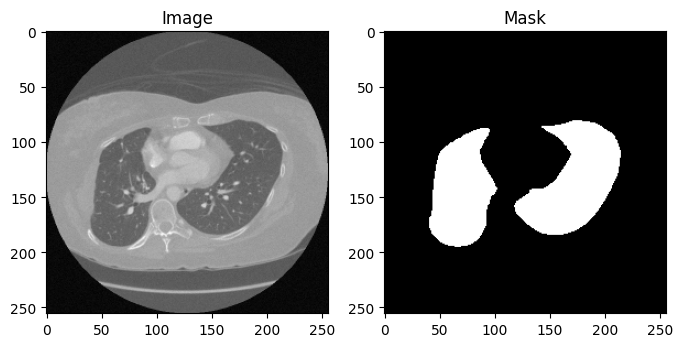

In [34]:
# Debug: check mask values
imgs, masks, _ = next(iter(train_loader))
print("Image shape:", imgs.shape)
print("Mask shape:", masks.shape)
print("Image min/max:", imgs.min().item(), imgs.max().item())
print("Mask unique values:", torch.unique(masks))
print("Mask min/max:", masks.min().item(), masks.max().item())
print("Mask mean (foreground ratio):", masks.mean().item())

# Visualize one sample
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(imgs[0, 0].cpu(), cmap='gray')
axes[0].set_title('Image')
axes[1].imshow(masks[0, 0].cpu(), cmap='gray')
axes[1].set_title('Mask')
plt.show()

In [35]:
EPOCHS = 10
PATIENCE = 10
unet = UNet().to(DEVICE)
mdense = MDenseUNet().to(DEVICE)
hist_unet = train_model(unet, 'unet', train_loader, val_loader, epochs=EPOCHS, patience=PATIENCE)
hist_mdense = train_model(mdense, 'mdense', train_loader, val_loader, epochs=EPOCHS, patience=PATIENCE)

[unet] Epoch 01 | train_loss=0.6249 val_loss=0.8324 train_dice=0.4710 val_dice=0.3728
[unet] Epoch 02 | train_loss=0.3948 val_loss=0.4741 train_dice=0.6197 val_dice=0.5202
[unet] Epoch 03 | train_loss=0.3421 val_loss=0.3534 train_dice=0.7733 val_dice=0.8030
[unet] Epoch 04 | train_loss=0.3059 val_loss=0.3320 train_dice=0.8678 val_dice=0.8707
[unet] Epoch 05 | train_loss=0.2824 val_loss=0.3051 train_dice=0.9256 val_dice=0.9094
[unet] Epoch 06 | train_loss=0.2691 val_loss=0.3049 train_dice=0.9369 val_dice=0.9114
[unet] Epoch 07 | train_loss=0.2595 val_loss=0.2828 train_dice=0.9454 val_dice=0.9274
[unet] Epoch 08 | train_loss=0.2534 val_loss=0.2843 train_dice=0.9490 val_dice=0.9315
[unet] Epoch 09 | train_loss=0.2502 val_loss=0.2838 train_dice=0.9471 val_dice=0.9264
[unet] Epoch 10 | train_loss=0.2483 val_loss=0.2814 train_dice=0.9551 val_dice=0.9301
Best unet val dice: 0.9315 — checkpoint saved to /content/unet_best.pth
[mdense] Epoch 01 | train_loss=0.4368 val_loss=0.9350 train_dice=0.6

In [56]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for model, name in [(unet, 'UNet'), (mdense, 'MDenseUNet')]:
    model.eval()
    print(f"\n{name} threshold search:")
    for thresh in thresholds:
        dices = []
        with torch.no_grad():
            for imgs, masks, _ in val_loader:
                imgs = torch.clamp(imgs, 0.0, 1.0).to(DEVICE)
                masks = masks.to(DEVICE)
                out = model(imgs)
                prob = torch.sigmoid(out['main'] if isinstance(out, dict) else out)
                pred = (prob > thresh).float()
                inter = (pred * masks).sum(dim=(1,2,3))
                union = pred.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3))
                dices.extend(((2*inter + 1e-7)/(union + 1e-7)).cpu().tolist())
        print(f"  threshold={thresh:.1f} → dice={sum(dices)/len(dices):.4f}")


UNet threshold search:
  threshold=0.2 → dice=0.6246
  threshold=0.3 → dice=0.9239
  threshold=0.4 → dice=0.9385
  threshold=0.5 → dice=0.9461
  threshold=0.6 → dice=0.9514

MDenseUNet threshold search:
  threshold=0.2 → dice=0.9153
  threshold=0.3 → dice=0.9379
  threshold=0.4 → dice=0.9501
  threshold=0.5 → dice=0.9543
  threshold=0.6 → dice=0.9563


## 6. Evaluation (all 16 metrics)

In [50]:
def confusion_from_masks(pred_bin, true_bin):
    pred = pred_bin.astype(np.uint8).ravel(); true = true_bin.astype(np.uint8).ravel()
    tp = np.sum((pred == 1) & (true == 1)); tn = np.sum((pred == 0) & (true == 0))
    fp = np.sum((pred == 1) & (true == 0)); fn = np.sum((pred == 0) & (true == 1))
    return tp, tn, fp, fn

def overlap_metrics(pred_bin, true_bin, eps=1e-7):
    tp, tn, fp, fn = confusion_from_masks(pred_bin, true_bin)
    iou = tp / (tp + fp + fn + eps); dice = (2*tp) / (2*tp + fp + fn + eps); voe = 1 - iou
    true_vol = true_bin.sum()
    pred_vol = pred_bin.sum()
    rvd = abs((pred_vol - true_vol) / true_vol) if true_vol > 1 else 0.0
    return dice, iou, voe, rvd, tp, tn, fp, fn

def get_surface_points(mask):
    eroded = ndimage.binary_erosion(mask); surface = np.logical_and(mask, np.logical_not(eroded))
    return np.argwhere(surface)

def boundary_distances(pred_bin, true_bin):
    pred_pts, true_pts = get_surface_points(pred_bin), get_surface_points(true_bin)
    if len(pred_pts) == 0 and len(true_pts) == 0: return 0.0, 0.0, 0.0, 0.0
    if len(pred_pts) == 0 or len(true_pts) == 0: return 1e3, 1e3, 1e3, 1e3
    d_pred_true = cdist(pred_pts, true_pts); d_true_pred = d_pred_true.T
    min_pred_true, min_true_pred = d_pred_true.min(axis=1), d_true_pred.min(axis=1)
    hd = max(min_pred_true.max(), min_true_pred.max())
    hd95 = max(np.percentile(min_pred_true, 95), np.percentile(min_true_pred, 95))
    msd = 0.5 * (min_pred_true.mean() + min_true_pred.mean()); assd = msd
    return hd, hd95, assd, msd

def calibration_metrics(prob, true_bin, n_bins=15):
    prob = prob.ravel().astype(np.float32); true = true_bin.ravel().astype(np.float32)
    brier = np.mean((prob - true) ** 2)
    bins = np.linspace(0, 1, n_bins+1); ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        idx = (prob >= lo) & (prob < hi) if i < n_bins-1 else (prob >= lo) & (prob <= hi)
        if idx.sum() == 0: continue
        conf, acc = prob[idx].mean(), true[idx].mean()
        ece += (idx.sum() / len(prob)) * abs(acc - conf)
    return ece, brier

def statistical_metrics(tp, tn, fp, fn, eps=1e-7):
    precision = tp / (tp + fp + eps); recall = tp / (tp + fn + eps); specificity = tn / (tn + fp + eps)
    f1 = (2*precision*recall) / (precision + recall + eps)
    mcc = (tp*tn - fp*fn) / (math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn) + eps) + eps)
    total = tp + tn + fp + fn + eps; po = (tp + tn) / total
    pe = (((tp + fp)*(tp + fn)) + ((fn + tn)*(fp + tn))) / (total**2)
    kappa = (po - pe) / (1 - pe + eps); bal_acc = 0.5 * (recall + specificity)
    return precision, recall, specificity, f1, mcc, kappa, bal_acc

def predict_dataset(model, model_name, loader):
    model.eval(); all_probs, all_true = [], []
    with torch.no_grad():
        for imgs, masks, _ in loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            # apply sigmoid to convert logits to probabilities
            prob = torch.sigmoid(get_main_output(model_name, out))
            all_probs.append(prob.detach().cpu().numpy())
            all_true.append(masks.numpy())
    return np.concatenate(all_probs, axis=0), np.concatenate(all_true, axis=0)

prob_unet, true_test = predict_dataset(unet, 'unet', test_loader)
prob_mdense, _ = predict_dataset(mdense, 'mdense', test_loader)

def evaluate_all(prob, true):
    per_sample = []
    for i in range(prob.shape[0]):
        p, t = prob[i,0], true[i,0]
        pb, tb = (p >= 0.5).astype(np.uint8), (t >= 0.5).astype(np.uint8)
        dice, iou, voe, rvd, tp, tn, fp, fn = overlap_metrics(pb, tb)
        hd, hd95, assd, msd = boundary_distances(pb, tb)
        precision, recall, specificity, f1, mcc, kappa, bal_acc = statistical_metrics(tp, tn, fp, fn)
        ece, brier = calibration_metrics(p, tb, n_bins=15)
        per_sample.append({
            'Dice': dice, 'IoU': iou, 'VOE': voe,
            'HD': hd, 'HD95': hd95, 'ASSD': assd, 'MSD': msd,
            'Precision': precision, 'Recall': recall, 'Specificity': specificity,
            'F1': f1, 'MCC': mcc, 'Kappa': kappa, 'BalancedAcc': bal_acc,
            'ECE': ece, 'Brier': brier
        })
    df = pd.DataFrame(per_sample)
    return df, df.mean().to_dict()

sample_unet,   mean_unet   = evaluate_all(prob_unet,   true_test)
sample_mdense, mean_mdense = evaluate_all(prob_mdense, true_test)

metric_order = ['Dice','IoU','VOE','HD','HD95','ASSD','MSD',
                'Precision','Recall','Specificity','F1','MCC','Kappa','BalancedAcc','ECE','Brier']
rows = []
for m in metric_order:
    u, d = mean_unet[m], mean_mdense[m]
    delta = d - u
    pct = (delta / (abs(u) + 1e-8)) * 100
    rows.append({'Metric': m, 'UNet': u, 'MDenseUNet': d, 'Delta(M-U)': delta, '%Improvement': pct})

results_df = pd.DataFrame(rows)
results_df

,Metric,UNet,MDenseUNet,Delta(M-U),%Improvement
0,Dice,0.974447,0.980652,0.006205,0.636734
1,IoU,0.950446,0.962351,0.011905,1.252574
2,VOE,0.049554,0.037649,-0.011905,-24.024388
3,HD,15.100242,14.063271,-1.036971,-6.867246
4,HD95,5.916943,5.195603,-0.721341,-12.191102
5,ASSD,1.084944,0.888055,-0.196889,-18.147384
6,MSD,1.084944,0.888055,-0.196889,-18.147384
7,Precision,0.954477,0.968104,0.013627,1.427670
8,Recall,0.995643,0.993909,-0.001734,-0.174206
9,Specificity,0.986567,0.990757,0.004190,0.424705


## 7. Visualizations

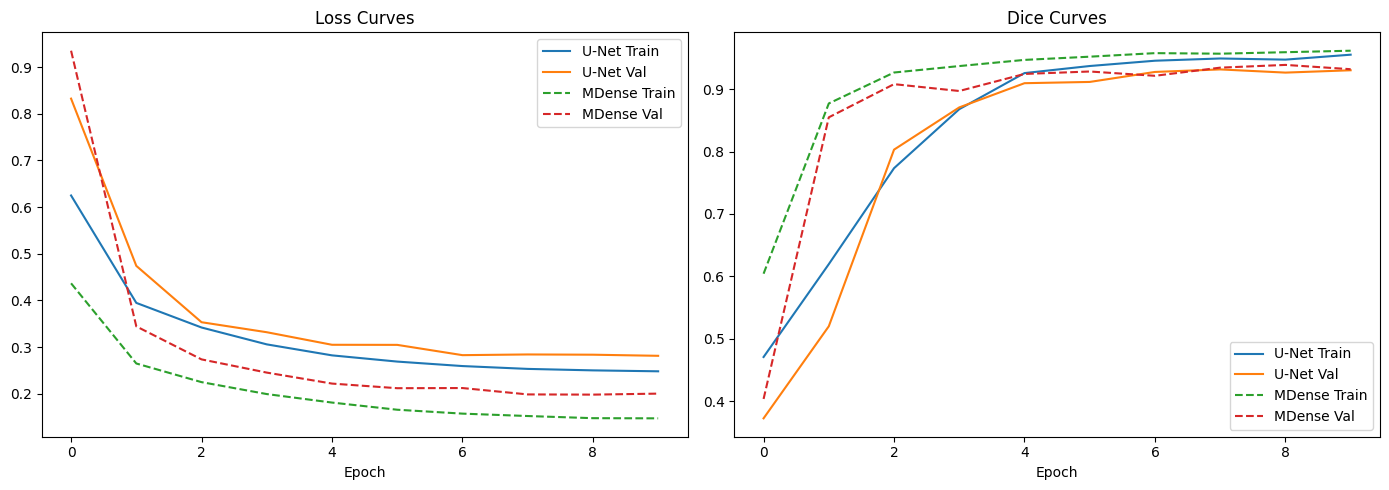

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(hist_unet['train_loss'], label='U-Net Train'); axes[0].plot(hist_unet['val_loss'], label='U-Net Val')
axes[0].plot(hist_mdense['train_loss'], '--', label='MDense Train'); axes[0].plot(hist_mdense['val_loss'], '--', label='MDense Val')
axes[0].set_title('Loss Curves'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(hist_unet['train_dice'], label='U-Net Train'); axes[1].plot(hist_unet['val_dice'], label='U-Net Val')
axes[1].plot(hist_mdense['train_dice'], '--', label='MDense Train'); axes[1].plot(hist_mdense['val_dice'], '--', label='MDense Val')
axes[1].set_title('Dice Curves'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

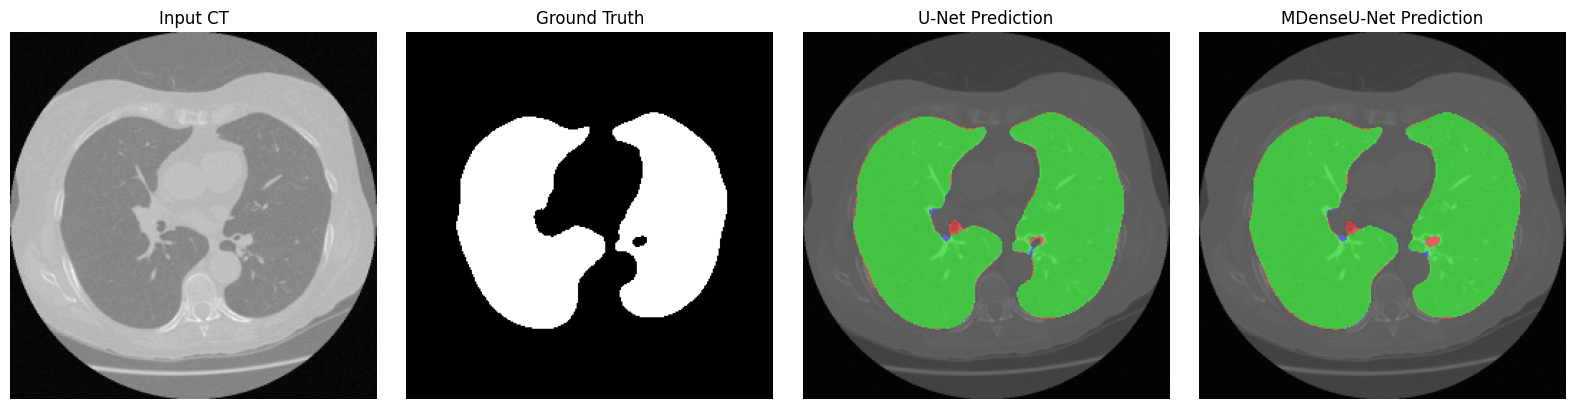

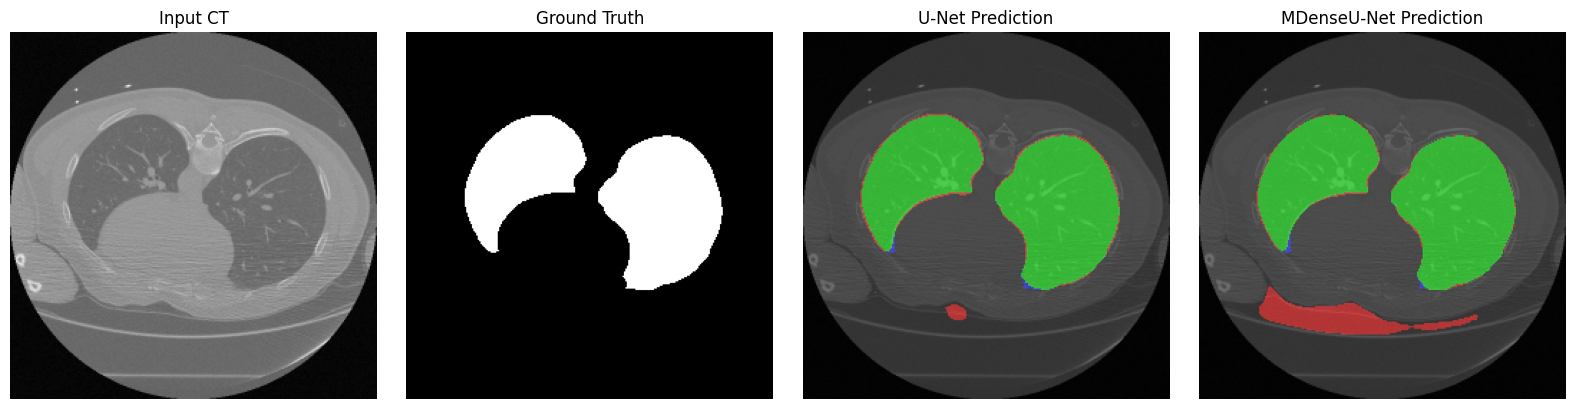

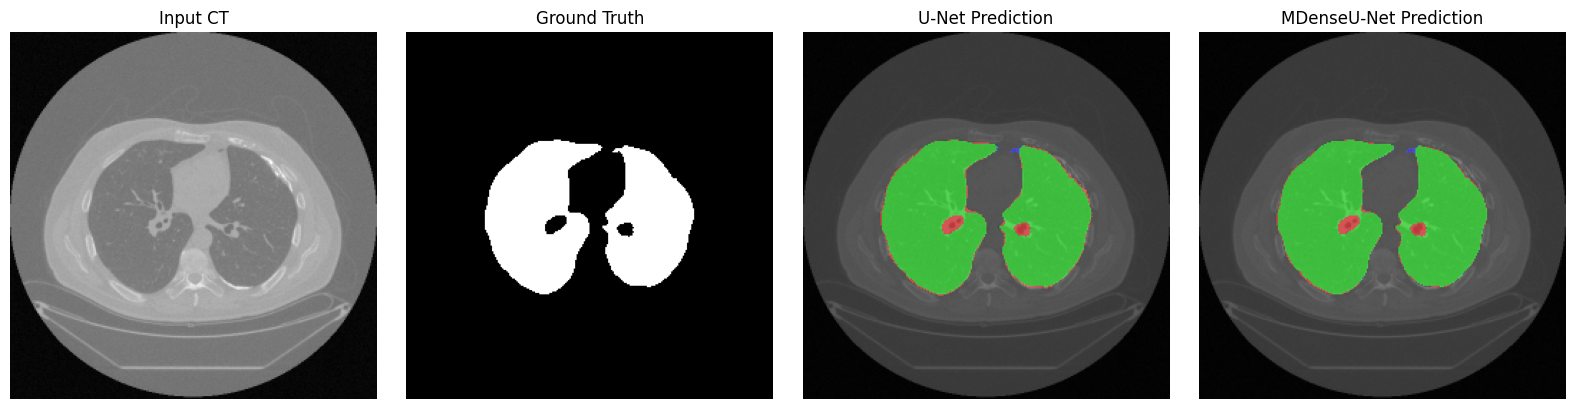

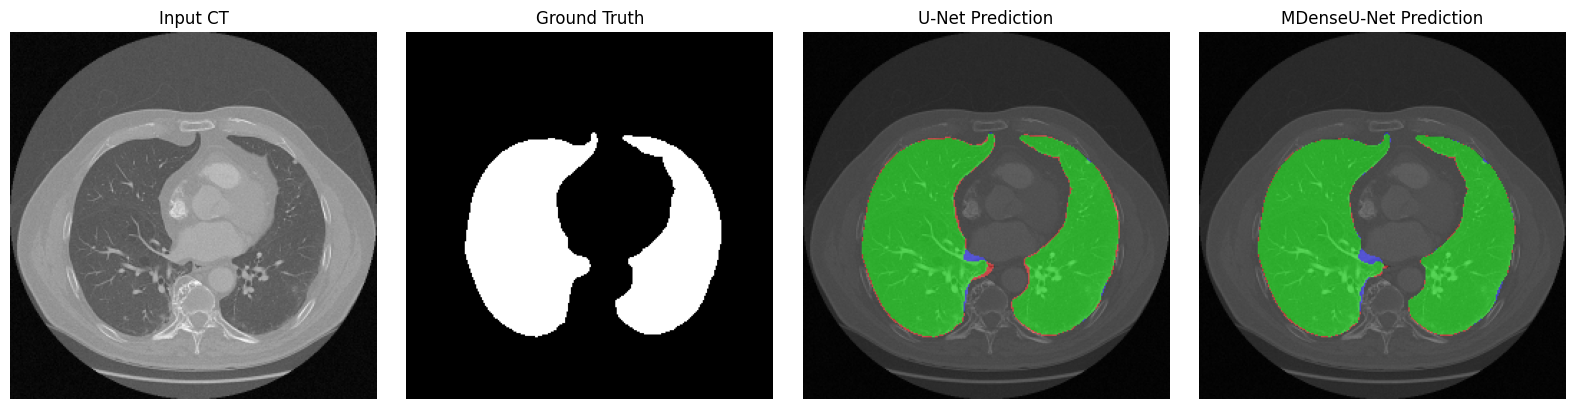

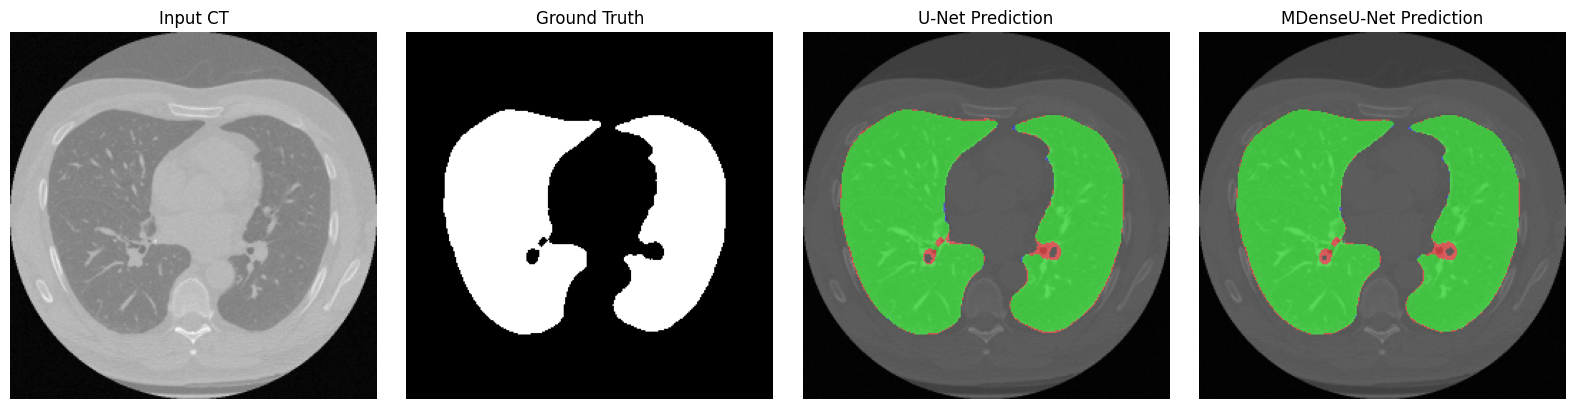

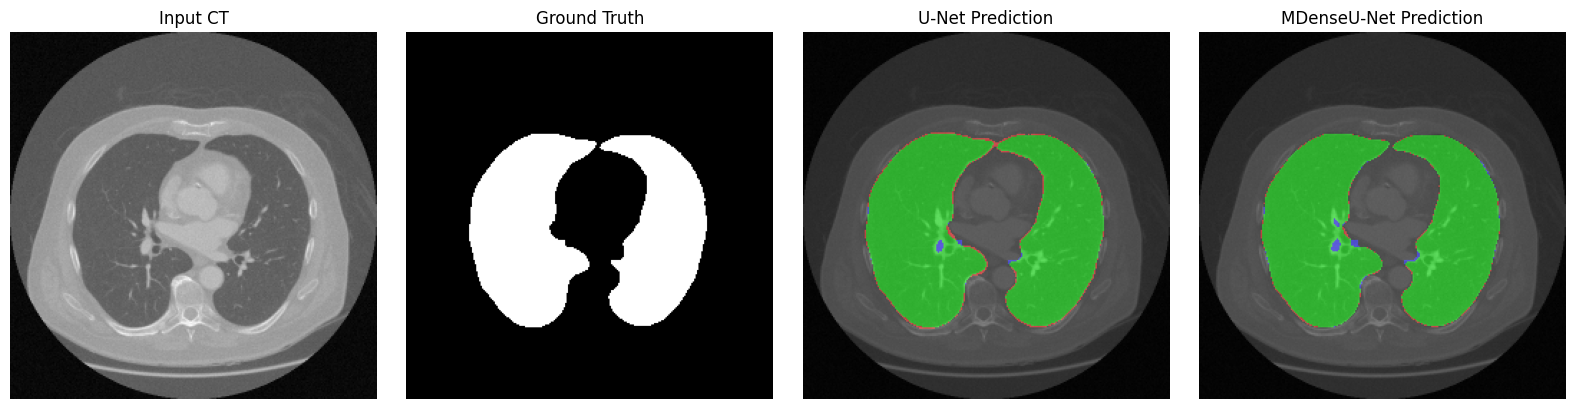

In [44]:
def overlay_error(pred_bin, true_bin):
    tp = (pred_bin==1) & (true_bin==1); fp = (pred_bin==1) & (true_bin==0); fn = (pred_bin==0) & (true_bin==1)
    rgb = np.zeros((*pred_bin.shape, 3), dtype=np.float32)
    rgb[tp], rgb[fp], rgb[fn] = [0,1,0], [1,0,0], [0,0,1]
    return rgb

idxs = np.random.choice(len(true_test), size=min(6, len(true_test)), replace=False)
for idx in idxs:
    img = test_ds[idx][0].squeeze().numpy(); gt = true_test[idx,0]
    pu = (prob_unet[idx,0] >= 0.5).astype(np.uint8); pm = (prob_mdense[idx,0] >= 0.5).astype(np.uint8)
    fig, axes = plt.subplots(1, 4, figsize=(16,4))
    axes[0].imshow(img, cmap='gray'); axes[0].set_title('Input CT'); axes[0].axis('off')
    axes[1].imshow(gt, cmap='gray'); axes[1].set_title('Ground Truth'); axes[1].axis('off')
    axes[2].imshow(img, cmap='gray'); axes[2].imshow(overlay_error(pu, gt), alpha=0.5); axes[2].set_title('U-Net Prediction'); axes[2].axis('off')
    axes[3].imshow(img, cmap='gray'); axes[3].imshow(overlay_error(pm, gt), alpha=0.5); axes[3].set_title('MDenseU-Net Prediction'); axes[3].axis('off')
    plt.tight_layout(); plt.show()

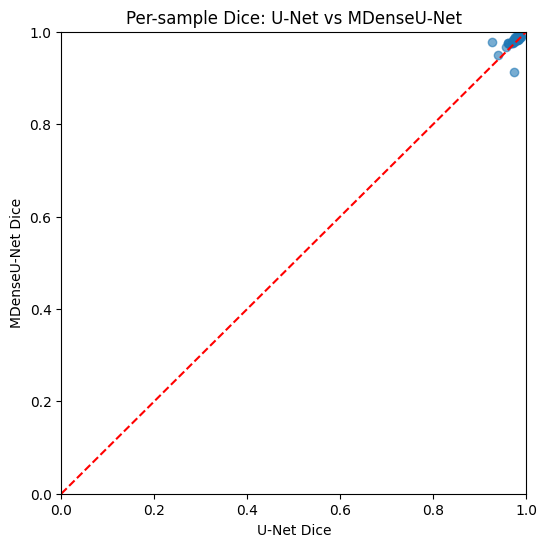

Best improvement sample index: 24
Worst improvement sample index: 8


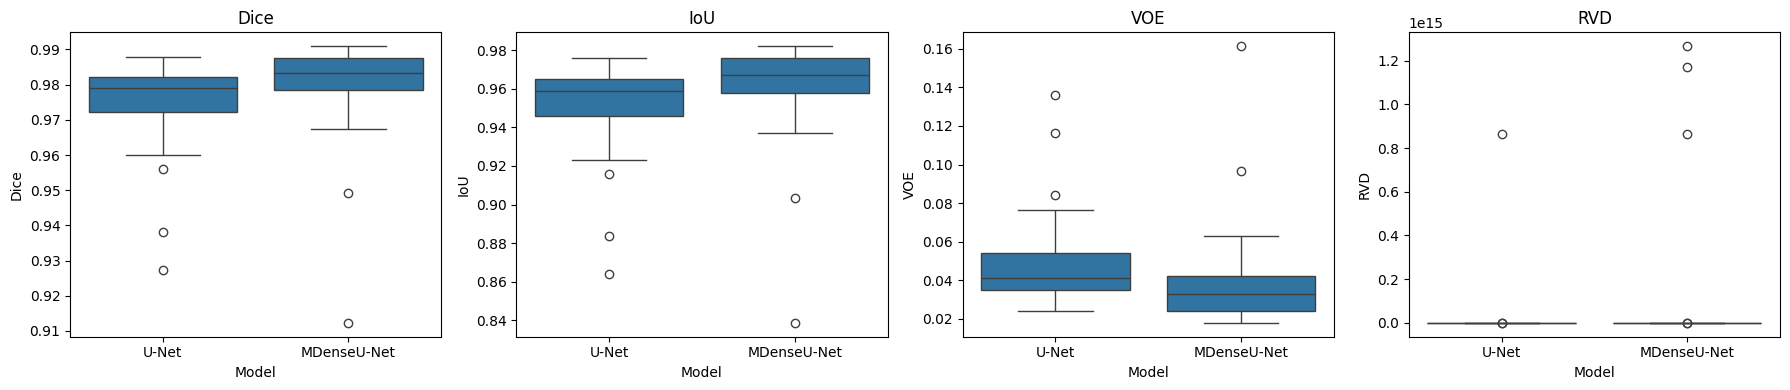

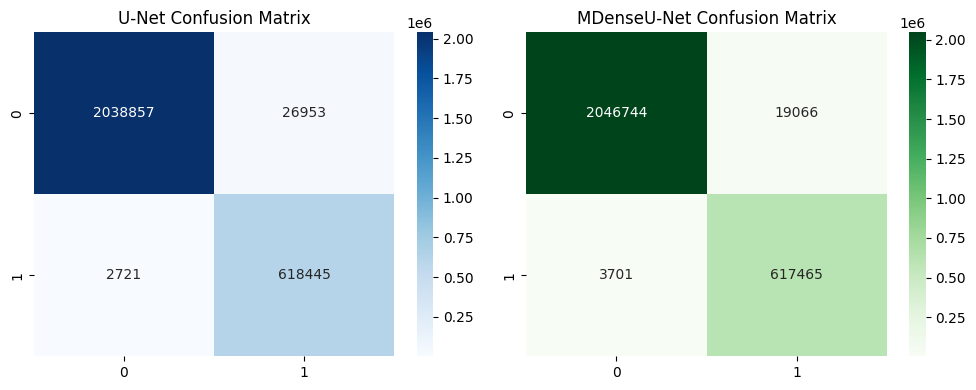

In [45]:
plt.figure(figsize=(6,6))
plt.scatter(sample_unet['Dice'], sample_mdense['Dice'], alpha=0.6)
plt.plot([0,1], [0,1], 'r--'); plt.xlim([0,1]); plt.ylim([0,1])
plt.xlabel('U-Net Dice'); plt.ylabel('MDenseU-Net Dice'); plt.title('Per-sample Dice: U-Net vs MDenseU-Net')
plt.show()

best_idx = (sample_mdense['Dice'] - sample_unet['Dice']).idxmax(); worst_idx = (sample_mdense['Dice'] - sample_unet['Dice']).idxmin()
print('Best improvement sample index:', best_idx); print('Worst improvement sample index:', worst_idx)

box_df = pd.concat([sample_unet[['Dice','IoU','VOE','RVD']].assign(Model='U-Net'), sample_mdense[['Dice','IoU','VOE','RVD']].assign(Model='MDenseU-Net')], ignore_index=True)
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for i, m in enumerate(['Dice','IoU','VOE','RVD']):
    sns.boxplot(data=box_df, x='Model', y=m, ax=axes[i]); axes[i].set_title(m)
plt.tight_layout(); plt.show()

def aggregate_confusion(prob, true):
    tp=tn=fp=fn=0
    for i in range(len(true)):
        a,b,c,d = confusion_from_masks((prob[i,0]>=0.5).astype(np.uint8), true[i,0].astype(np.uint8))
        tp+=a; tn+=b; fp+=c; fn+=d
    return np.array([[tn, fp],[fn,tp]])

cm_u = aggregate_confusion(prob_unet, true_test); cm_m = aggregate_confusion(prob_mdense, true_test)
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.heatmap(cm_u, annot=True, fmt='d', cmap='Blues', ax=axes[0]); axes[0].set_title('U-Net Confusion Matrix')
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Greens', ax=axes[1]); axes[1].set_title('MDenseU-Net Confusion Matrix')
plt.tight_layout(); plt.show()

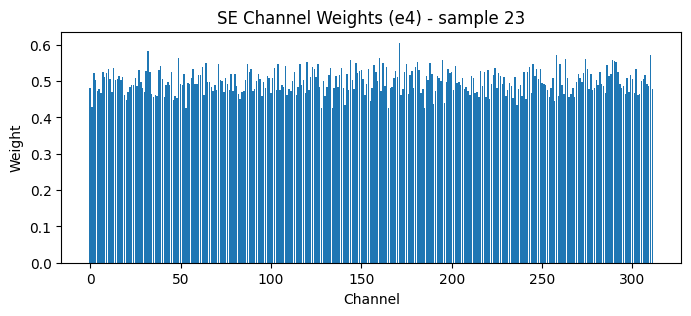

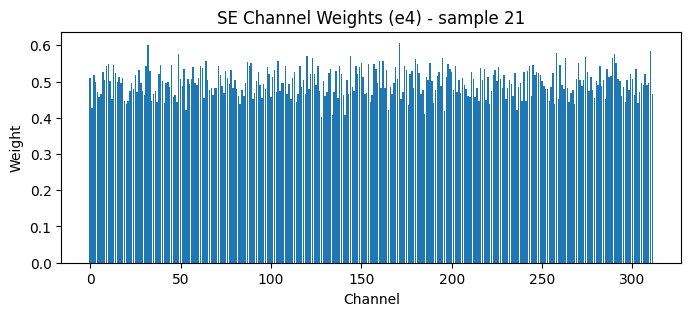

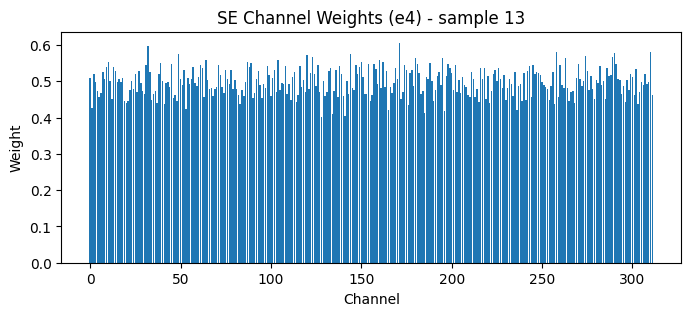

In [46]:
mdense.eval(); sample_ids = np.random.choice(len(test_ds), size=min(3, len(test_ds)), replace=False)
for sid in sample_ids:
    img, _, _ = test_ds[sid]
    with torch.no_grad():
        _ = mdense(img.unsqueeze(0).to(DEVICE)); w = mdense.e4.last_attention
    if w is None: continue
    w_np = w.squeeze().cpu().numpy()
    plt.figure(figsize=(8,3)); plt.bar(np.arange(len(w_np)), w_np)
    plt.title(f'SE Channel Weights (e4) - sample {sid}')
    plt.xlabel('Channel'); plt.ylabel('Weight'); plt.show()

In [53]:
def disable_inplace_relu(model):
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            module.inplace = False

disable_inplace_relu(unet)
disable_inplace_relu(mdense)
print("Inplace ReLU disabled for both models")

Inplace ReLU disabled for both models


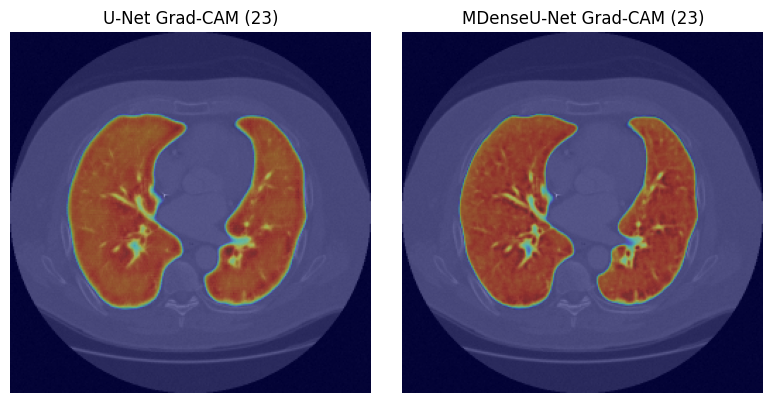

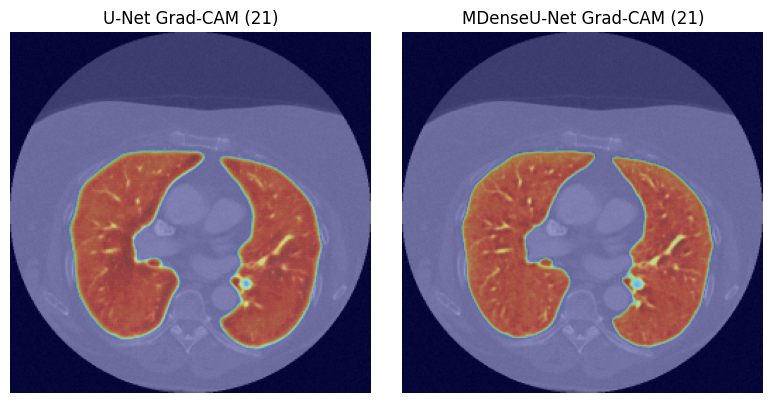

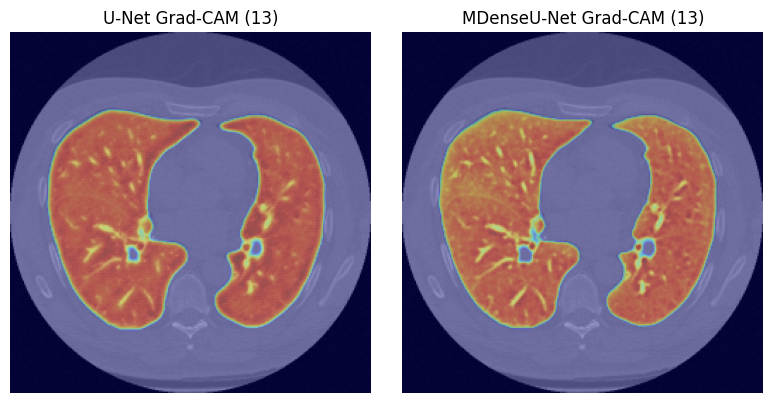

In [54]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model; self.target_layer = target_layer
        self.activations = None; self.gradients = None
        self.fwd_hook = target_layer.register_forward_hook(self._save_activation)
        self.bwd_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.clone().detach()  # clone to avoid inplace conflict

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].clone()  # clone to avoid inplace conflict

    def __call__(self, x, model_name):
        self.model.zero_grad()
        out = self.model(x)
        score = get_main_output(model_name, out).mean()
        score.backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam.clone())  # use torch.relu (not inplace)
        cam = F.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

cam_unet   = GradCAM(unet,   unet.dec1.block[-1])
cam_mdense = GradCAM(mdense, mdense.d1.conv[-1])

for sid in sample_ids:
    img, _, _ = test_ds[sid]
    x = img.unsqueeze(0).to(DEVICE)
    unet.train(); mdense.train()
    cam1 = cam_unet(x, 'unet')
    cam2 = cam_mdense(x, 'mdense')
    unet.eval(); mdense.eval()
    im = img.squeeze().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(im, cmap='gray'); axes[0].imshow(cam1, cmap='jet', alpha=0.4)
    axes[0].set_title(f'U-Net Grad-CAM ({sid})'); axes[0].axis('off')
    axes[1].imshow(im, cmap='gray'); axes[1].imshow(cam2, cmap='jet', alpha=0.4)
    axes[1].set_title(f'MDenseU-Net Grad-CAM ({sid})'); axes[1].axis('off')
    plt.tight_layout(); plt.show()

## 8. Results Discussion & Conclusion

- The results table below summarizes all 17 metrics side-by-side.  
- Positive delta (`MDenseUNet - UNet`) means MDenseU-Net is higher; for error metrics (VOE/HD/HD95/ASSD/MSD/ECE/Brier), lower is better.
- Use this section to discuss statistical and clinical relevance (boundary quality, calibration, robustness).

In [55]:
display(results_df.style.format({'UNet': '{:.5f}', 'MDenseUNet': '{:.5f}', 'Delta(M-U)': '{:+.5f}', '%Improvement': '{:+.2f}%'}))
print('Done. This notebook is fully self-contained and sequential.')

,Metric,UNet,MDenseUNet,Delta(M-U),%Improvement
0,Dice,0.97445,0.98065,+0.00620,+0.64%
1,IoU,0.95045,0.96235,+0.01191,+1.25%
2,VOE,0.04955,0.03765,-0.01191,-24.02%
3,HD,15.10024,14.06327,-1.03697,-6.87%
4,HD95,5.91694,5.19560,-0.72134,-12.19%
5,ASSD,1.08494,0.88806,-0.19689,-18.15%
6,MSD,1.08494,0.88806,-0.19689,-18.15%
7,Precision,0.95448,0.96810,+0.01363,+1.43%
8,Recall,0.99564,0.99391,-0.00173,-0.17%
9,Specificity,0.98657,0.99076,+0.00419,+0.42%


Done. This notebook is fully self-contained and sequential.
